In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

from sklearn.metrics import mean_squared_error, mean_absolute_error


In [2]:
DATA_PATH = "../data/processed/passthrough_dataset.csv"  # adjust if needed

df = pd.read_csv(DATA_PATH, parse_dates=["date"]).set_index("date")
df = df.asfreq("ME")  # month-end frequency (consistent with your project)
df.head()


,brent,wti,usdmyr,ron95,ron97,diesel,cpi_transport,cpi_headline
date,,,,,,,,
2020-01-31,63.645455,57.519048,4.080110,2.0800,2.5725,2.1800,115.0,122.4
2020-02-29,55.657000,50.542632,4.159900,2.0680,2.3780,2.1340,113.9,122.4
2020-03-31,32.011364,29.207727,4.298409,1.6325,1.9275,1.8150,104.0,120.9
2020-04-30,18.378500,16.547619,4.352486,1.2625,1.5625,1.4675,90.0,117.6
2020-05-31,29.378947,28.562500,4.340906,1.3240,1.6240,1.4740,90.9,117.9


In [3]:
TARGETS = ["ron95", "ron97", "diesel", "cpi_transport", "cpi_headline"]


In [4]:
EXOG_BASE = ["usdmyr"]  # always reasonable

EXOG_OIL_BRENT = ["brent"]
EXOG_OIL_WTI   = ["wti"]

# Policy dummies (if they exist in your dataset). If not, we create them.
if "ron95_policy" not in df.columns:
    df["ron95_policy"] = (df.index >= "2025-09-01").astype(int)
if "diesel_policy" not in df.columns:
    df["diesel_policy"] = (df.index >= "2024-06-01").astype(int)  # example, change if your real rule differs
# ron97 policy dummy if you use it:
if "ron97_policy" not in df.columns:
    df["ron97_policy"] = (df.index >= "2025-09-01").astype(int)


In [5]:
EXOG_MAP = {
    "ron95": EXOG_BASE + EXOG_OIL_WTI + ["ron95_policy"],
    "ron97": EXOG_BASE + EXOG_OIL_WTI + ["ron97_policy"],
    "diesel": EXOG_BASE + EXOG_OIL_WTI + ["diesel_policy"],
    "cpi_transport": ["ron97", "diesel"],  # structural chain driver
    "cpi_headline": ["cpi_transport"],     # structural chain driver
}


In [6]:
# Keep only what we need
needed_cols = sorted(set(TARGETS + sum(EXOG_MAP.values(), [])))
data = df[needed_cols].copy()

# Ensure numeric
data = data.apply(pd.to_numeric, errors="coerce")

# Drop rows where any needed columns are missing
data = data.dropna()

data.tail(), data.shape


(            cpi_headline  cpi_transport  diesel  diesel_policy   ron95  \
 date                                                                     
 2025-07-31         134.7          122.6  2.8920              1  2.0500   
 2025-08-31         134.9          122.5  2.8925              1  2.0500   
 2025-09-30         135.2          122.7  2.9140              1  2.1600   
 2025-10-31         135.1          121.6  2.9250              1  2.6000   
 2025-11-30         135.1          121.6  3.0675              1  2.6325   
 
             ron95_policy   ron97  ron97_policy    usdmyr        wti  
 date                                                                 
 2025-07-31             0  3.1900             0  4.233696  68.390909  
 2025-08-31             0  3.1475             0  4.225881  64.864286  
 2025-09-30             1  3.1940             1  4.212500  63.959048  
 2025-10-31             1  3.1750             1  4.215818  60.894545  
 2025-11-30             1  3.2475             1

In [7]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    eps = 1e-9
    return float(np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100)


In [8]:
TRAIN_END = "2023-12-31"  # adjust if you want
HORIZONS = [1, 3, 6]


In [9]:
@dataclass
class ForecastResult:
    target: str
    model: str
    horizon: int
    origin: pd.Timestamp
    y_true: float
    y_pred: float
    lo95: Optional[float] = None
    hi95: Optional[float] = None


In [10]:
def fit_forecast_arima(y_train, steps, order=(1,1,1)):
    m = SARIMAX(y_train, order=order, trend="c",
                enforce_stationarity=False, enforce_invertibility=False)
    res = m.fit(disp=False)
    fc = res.get_forecast(steps=steps)
    mean = fc.predicted_mean
    ci = fc.conf_int(alpha=0.05)
    return mean, ci


In [11]:
def fit_forecast_arimax(y_train, X_train, X_future, steps, order=(1,1,1)):
    m = SARIMAX(y_train, exog=X_train, order=order, trend="c",
                enforce_stationarity=False, enforce_invertibility=False)
    res = m.fit(disp=False)
    fc = res.get_forecast(steps=steps, exog=X_future)
    mean = fc.predicted_mean
    ci = fc.conf_int(alpha=0.05)
    return mean, ci


In [12]:
def fit_forecast_ets(y_train, steps, error="add", trend="add", seasonal=None, seasonal_periods=None):
    m = ETSModel(y_train, error=error, trend=trend, seasonal=seasonal, seasonal_periods=seasonal_periods)
    res = m.fit(disp=False)
    pred = res.forecast(steps)
    # No intervals here (keep it simple and defensible)
    return pred


In [13]:
def rolling_forecast(
    data: pd.DataFrame,
    target: str,
    exog_cols: Optional[List[str]],
    train_end: str,
    horizons: List[int],
    arima_order=(1,1,1),
    arimax_order=(1,1,1),
    ets_cfg=("add","add",None,None),
):
    results: List[ForecastResult] = []

    y = data[target].copy()
    X = data[exog_cols].copy() if exog_cols else None

    # Define rolling origins = each month after train_end where we can forecast max horizon
    train_end = pd.Timestamp(train_end)
    all_dates = y.index

    origins = all_dates[all_dates > train_end]
    max_h = max(horizons)

    # Ensure we have enough future observations for max horizon
    origins = [t for t in origins if (t + pd.offsets.MonthEnd(max_h)) in all_dates]

    for origin in origins:
        y_train = y.loc[:origin].iloc[:-1]  # train up to month BEFORE origin
        # the "origin" is the first OOS month we want to predict (t)

        for h in horizons:
            target_date = origin + pd.offsets.MonthEnd(h-1)  # origin is h=1 target

            # Train series up to month before origin
            y_tr = y.loc[:origin].iloc[:-1]

            # True value at target_date
            y_true = float(y.loc[target_date])

            # ---------- ARIMA ----------
            mean, ci = fit_forecast_arima(y_tr, steps=h, order=arima_order)
            y_pred = float(mean.iloc[-1])
            lo95 = float(ci.iloc[-1, 0])
            hi95 = float(ci.iloc[-1, 1])

            results.append(ForecastResult(
                target=target, model=f"ARIMA{arima_order}", horizon=h,
                origin=origin, y_true=y_true, y_pred=y_pred, lo95=lo95, hi95=hi95
            ))

            # ---------- ARIMAX ----------
            if exog_cols:
                X_tr = X.loc[:origin].iloc[:-1]
                X_future = X.loc[origin:target_date]  # includes origin month through target month
                # For SARIMAX, X_future must have exactly h rows corresponding to forecast steps
                X_future = X_future.iloc[:h]

                mean_x, ci_x = fit_forecast_arimax(y_tr, X_tr, X_future, steps=h, order=arimax_order)
                y_pred_x = float(mean_x.iloc[-1])
                lo95_x = float(ci_x.iloc[-1, 0])
                hi95_x = float(ci_x.iloc[-1, 1])

                results.append(ForecastResult(
                    target=target, model=f"ARIMAX{arimax_order}", horizon=h,
                    origin=origin, y_true=y_true, y_pred=y_pred_x, lo95=lo95_x, hi95=hi95_x
                ))

            # ---------- ETS ----------
            ets_error, ets_trend, ets_seasonal, ets_sp = ets_cfg
            pred_ets = fit_forecast_ets(y_tr, steps=h,
                                        error=ets_error, trend=ets_trend,
                                        seasonal=ets_seasonal, seasonal_periods=ets_sp)
            y_pred_e = float(pred_ets.iloc[-1])

            results.append(ForecastResult(
                target=target, model=f"ETS({ets_error},{ets_trend},{ets_seasonal})", horizon=h,
                origin=origin, y_true=y_true, y_pred=y_pred_e
            ))

    return results


In [14]:
r95_results = rolling_forecast(
    data=data,
    target="ron95",
    exog_cols=EXOG_MAP["ron95"],
    train_end=TRAIN_END,
    horizons=HORIZONS,
    arima_order=(1,1,1),
    arimax_order=(1,1,1),
    ets_cfg=("add","add",None,None),
)

len(r95_results), r95_results[:3]


C:\Users\yievi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\yievi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\yievi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\yievi\AppData\Local\Packages

(153,
 [ForecastResult(target='ron95', model='ARIMA(1, 1, 1)', horizon=1, origin=Timestamp('2024-01-31 00:00:00'), y_true=2.05, y_pred=2.0585542030169575, lo95=1.9761100257513649, hi95=2.14099838028255),
  ForecastResult(target='ron95', model='ARIMAX(1, 1, 1)', horizon=1, origin=Timestamp('2024-01-31 00:00:00'), y_true=2.05, y_pred=2.063832671222085, lo95=1.9833465429697097, hi95=2.1443187994744606),
  ForecastResult(target='ron95', model='ETS(add,add,None)', horizon=1, origin=Timestamp('2024-01-31 00:00:00'), y_true=2.05, y_pred=2.0493617534777977, lo95=None, hi95=None)])

In [15]:
r95_df = pd.DataFrame([r.__dict__ for r in r95_results])
r95_df.head()


,target,model,horizon,origin,y_true,y_pred,lo95,hi95
0,ron95,"ARIMA(1, 1, 1)",1,2024-01-31,2.05,2.058554,1.976110,2.140998
1,ron95,"ARIMAX(1, 1, 1)",1,2024-01-31,2.05,2.063833,1.983347,2.144319
2,ron95,"ETS(add,add,None)",1,2024-01-31,2.05,2.049362,NaN,NaN
3,ron95,"ARIMA(1, 1, 1)",3,2024-01-31,2.05,2.094431,1.835977,2.352886
4,ron95,"ARIMAX(1, 1, 1)",3,2024-01-31,2.05,2.104717,1.852706,2.356728


In [16]:
def summarize_metrics(df_res: pd.DataFrame):
    rows = []
    for (model, h), g in df_res.groupby(["model", "horizon"]):
        rows.append({
            "model": model,
            "horizon": int(h),
            "RMSE": rmse(g["y_true"], g["y_pred"]),
            "MAE": mae(g["y_true"], g["y_pred"]),
            "MAPE_%": mape(g["y_true"], g["y_pred"]),
            "n_forecasts": len(g),
        })
    out = pd.DataFrame(rows).sort_values(["horizon", "RMSE"])
    return out

summarize_metrics(r95_df)


,model,horizon,RMSE,MAE,MAPE_%,n_forecasts
6,"ETS(add,add,None)",1,0.000552,0.000549,0.026798,17
0,"ARIMA(1, 1, 1)",1,0.007349,0.007317,0.356930,17
3,"ARIMAX(1, 1, 1)",1,0.009068,0.007639,0.372630,17
7,"ETS(add,add,None)",3,0.001654,0.001648,0.080389,17
1,"ARIMA(1, 1, 1)",3,0.038193,0.038026,1.854909,17
4,"ARIMAX(1, 1, 1)",3,0.038356,0.037158,1.812577,17
8,"ETS(add,add,None)",6,0.136891,0.042119,1.702524,17
5,"ARIMAX(1, 1, 1)",6,0.140235,0.105071,4.834998,17
2,"ARIMA(1, 1, 1)",6,0.143153,0.109364,5.042538,17


In [17]:
def interval_coverage(df_res: pd.DataFrame):
    g = df_res.dropna(subset=["lo95","hi95"])
    if g.empty:
        return None
    covered = ((g["y_true"] >= g["lo95"]) & (g["y_true"] <= g["hi95"])).mean()
    return float(covered)

# coverage by model
for m in r95_df["model"].unique():
    cov = interval_coverage(r95_df[r95_df["model"] == m])
    if cov is not None:
        print(m, "coverage:", round(cov, 3))


ARIMA(1, 1, 1) coverage: 0.98
ARIMAX(1, 1, 1) coverage: 0.98


In [18]:
all_results = []

for tgt in ["ron97", "diesel", "cpi_transport", "cpi_headline"]:
    print(f"Running rolling forecasts for: {tgt}")
    
    res_list = rolling_forecast(
        data=data,
        target=tgt,
        exog_cols=EXOG_MAP[tgt],
        train_end=TRAIN_END,
        horizons=HORIZONS,
        arima_order=(1,1,1),
        arimax_order=(1,1,1),
        ets_cfg=("add","add",None,None),
    )
    all_results.extend(res_list)

# include your already computed RON95 results too
all_results.extend(r95_results)

df_all = pd.DataFrame([r.__dict__ for r in all_results])
df_all.head(), df_all.shape


Running rolling forecasts for: ron97


C:\Users\yievi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\yievi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\yievi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\yievi\AppData\Local\Packages

Running rolling forecasts for: diesel


C:\Users\yievi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\yievi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\yievi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\yievi\AppData\Local\Packages

Running rolling forecasts for: cpi_transport
Running rolling forecasts for: cpi_headline


(  target              model  horizon     origin  y_true    y_pred      lo95  \
 0  ron97     ARIMA(1, 1, 1)        1 2024-01-31    3.47  3.489596  3.179762   
 1  ron97    ARIMAX(1, 1, 1)        1 2024-01-31    3.47  3.547999  3.308540   
 2  ron97  ETS(add,add,None)        1 2024-01-31    3.47  3.487379       NaN   
 3  ron97     ARIMA(1, 1, 1)        3 2024-01-31    3.47  3.563777  2.803310   
 4  ron97    ARIMAX(1, 1, 1)        3 2024-01-31    3.47  3.709997  3.139333   
 
        hi95  
 0  3.799430  
 1  3.787458  
 2       NaN  
 3  4.324243  
 4  4.280660  ,
 (765, 8))

In [19]:
def summarize_metrics_by_target(df_all: pd.DataFrame):
    out_rows = []
    for (tgt, model, h), g in df_all.groupby(["target", "model", "horizon"]):
        out_rows.append({
            "target": tgt,
            "model": model,
            "horizon": int(h),
            "RMSE": rmse(g["y_true"], g["y_pred"]),
            "MAE": mae(g["y_true"], g["y_pred"]),
            "MAPE_%": mape(g["y_true"], g["y_pred"]),
            "n_forecasts": len(g),
        })
    return (pd.DataFrame(out_rows)
            .sort_values(["target", "horizon", "RMSE"])
            .reset_index(drop=True))

metrics_all = summarize_metrics_by_target(df_all)
metrics_all


,target,model,horizon,RMSE,MAE,MAPE_%,n_forecasts
0,cpi_headline,"ARIMAX(1, 1, 1)",1,0.168523,0.130996,0.098464,17
1,cpi_headline,"ETS(add,add,None)",1,0.189270,0.131326,0.098647,17
2,cpi_headline,"ARIMA(1, 1, 1)",1,0.242597,0.196966,0.147999,17
3,cpi_headline,"ARIMAX(1, 1, 1)",3,0.269375,0.226807,0.170231,17
4,cpi_headline,"ETS(add,add,None)",3,0.296196,0.268931,0.201661,17
5,cpi_headline,"ARIMA(1, 1, 1)",3,0.383844,0.332493,0.249090,17
6,cpi_headline,"ARIMAX(1, 1, 1)",6,0.340646,0.241706,0.180931,17
7,cpi_headline,"ETS(add,add,None)",6,0.413699,0.320974,0.240153,17
8,cpi_headline,"ARIMA(1, 1, 1)",6,0.659164,0.572241,0.427401,17
9,cpi_transport,"ETS(add,add,None)",1,0.418615,0.341122,0.279939,17


In [20]:
best_by_rmse = (
    metrics_all.sort_values(["target", "horizon", "RMSE"])
    .groupby(["target", "horizon"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

best_by_rmse


,target,model,horizon,RMSE,MAE,MAPE_%,n_forecasts
0,cpi_headline,"ARIMAX(1, 1, 1)",1,0.168523,0.130996,0.098464,17
1,cpi_headline,"ARIMAX(1, 1, 1)",3,0.269375,0.226807,0.170231,17
2,cpi_headline,"ARIMAX(1, 1, 1)",6,0.340646,0.241706,0.180931,17
3,cpi_transport,"ETS(add,add,None)",1,0.418615,0.341122,0.279939,17
4,cpi_transport,"ETS(add,add,None)",3,1.232753,1.141055,0.935428,17
5,cpi_transport,"ETS(add,add,None)",6,1.947486,1.752631,1.434561,17
6,diesel,"ARIMAX(1, 1, 1)",1,0.253644,0.120548,3.905821,17
7,diesel,"ARIMAX(1, 1, 1)",3,0.499577,0.329808,10.704367,17
8,diesel,"ARIMAX(1, 1, 1)",6,0.566694,0.435231,14.173202,17
9,ron95,"ETS(add,add,None)",1,0.000552,0.000549,0.026798,17


In [21]:
coverage_rows = []
for (tgt, model), g in df_all.groupby(["target", "model"]):
    cov = interval_coverage(g)
    if cov is not None:
        coverage_rows.append({
            "target": tgt,
            "model": model,
            "coverage_95": cov,
            "n_with_intervals": int(g.dropna(subset=["lo95","hi95"]).shape[0])
        })

coverage_df = pd.DataFrame(coverage_rows).sort_values(["target", "model"]).reset_index(drop=True)
coverage_df


,target,model,coverage_95,n_with_intervals
0,cpi_headline,"ARIMA(1, 1, 1)",1.000000,51
1,cpi_headline,"ARIMAX(1, 1, 1)",1.000000,51
2,cpi_transport,"ARIMA(1, 1, 1)",1.000000,51
3,cpi_transport,"ARIMAX(1, 1, 1)",0.803922,51
4,diesel,"ARIMA(1, 1, 1)",0.745098,51
5,diesel,"ARIMAX(1, 1, 1)",0.686275,51
6,ron95,"ARIMA(1, 1, 1)",0.980392,51
7,ron95,"ARIMAX(1, 1, 1)",0.980392,51
8,ron97,"ARIMA(1, 1, 1)",1.000000,51
9,ron97,"ARIMAX(1, 1, 1)",1.000000,51


In [23]:
OUT_DIR = "../data/outputs"

df_all.to_csv(f"{OUT_DIR}/rolling_forecasts_all.csv", index=False)
metrics_all.to_csv(f"{OUT_DIR}/forecast_metrics_all.csv", index=False)
best_by_rmse.to_csv(f"{OUT_DIR}/forecast_best_by_rmse.csv", index=False)
coverage_df.to_csv(f"{OUT_DIR}/forecast_interval_coverage.csv", index=False)

print("Saved:")
print(f"- {OUT_DIR}/rolling_forecasts_all.csv")
print(f"- {OUT_DIR}/forecast_metrics_all.csv")
print(f"- {OUT_DIR}/forecast_best_by_rmse.csv")
print(f"- {OUT_DIR}/forecast_interval_coverage.csv")


Saved:
- ../data/outputs/rolling_forecasts_all.csv
- ../data/outputs/forecast_metrics_all.csv
- ../data/outputs/forecast_best_by_rmse.csv
- ../data/outputs/forecast_interval_coverage.csv


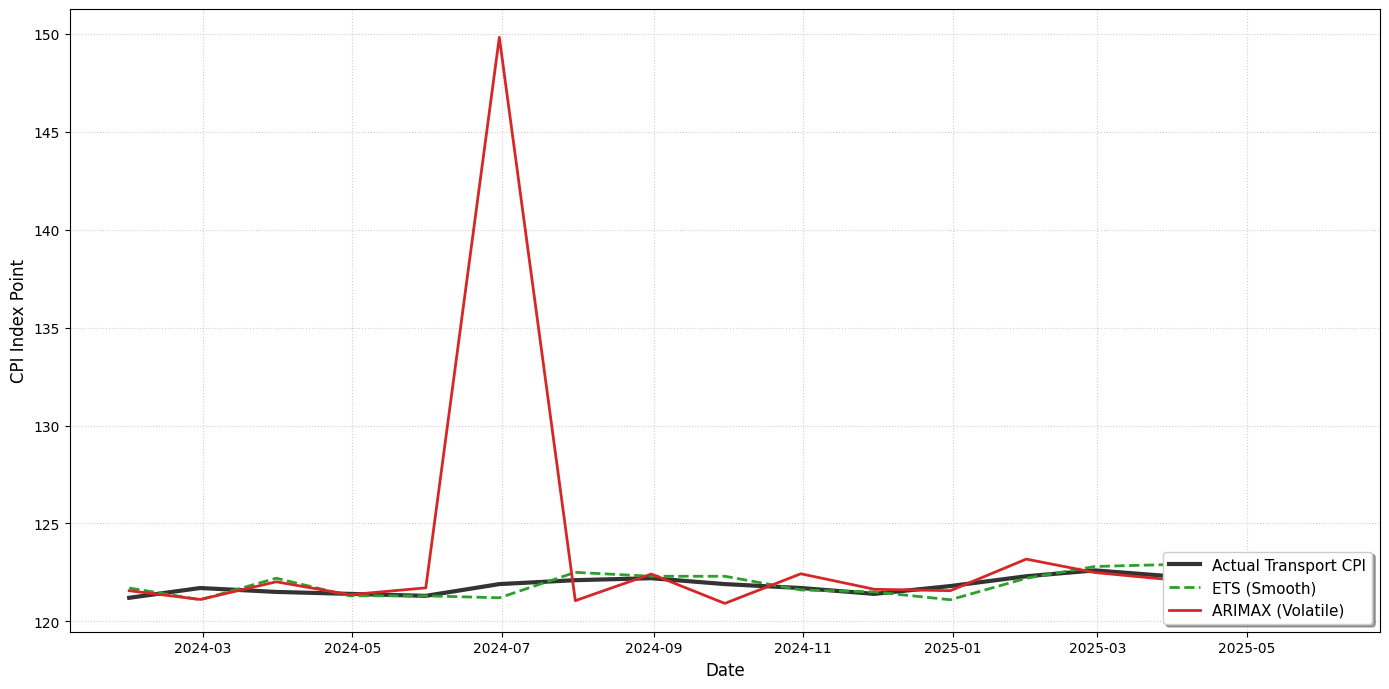

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the forecast results
results_path = "../data/outputs/rolling_forecasts_all.csv"
res_df = pd.read_csv(results_path, parse_dates=['origin'])

# 2. Filter for Transport CPI and Horizon=1 (One-Step Ahead Forecast)
target_var = 'cpi_transport'
horizon_step = 1 
subset = res_df[
    (res_df['target'] == target_var) & 
    (res_df['horizon'] == horizon_step)
].copy()

# Sort by date to ensure the line plot is correct
subset = subset.sort_values('origin')

# 3. Create the Plot
plt.figure(figsize=(14, 7))

# Plot Actuals (We only need one line for actuals, take it from any model's rows)
# We use 'origin' as the x-axis (the time the forecast was made for the next step)
actuals = subset[subset['model'].str.contains('ARIMA')].set_index('origin')['y_true']
plt.plot(actuals.index, actuals, label='Actual Transport CPI', color='black', linewidth=3, alpha=0.8)

# Plot ETS (The Smooth Line)
ets_data = subset[subset['model'].str.contains('ETS')]
plt.plot(ets_data['origin'], ets_data['y_pred'], label='ETS (Smooth)', color='#2ca02c', linewidth=2, linestyle='--')

# Plot ARIMAX (The Volatile Line)
arimax_data = subset[subset['model'].str.contains('ARIMAX')]
plt.plot(arimax_data['origin'], arimax_data['y_pred'], label='ARIMAX (Volatile)', color='#d62728', linewidth=2)

# Styling

plt.ylabel('CPI Index Point', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='lower right', frameon=True, shadow=True, fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)



plt.tight_layout()
plt.show()